#### Model construction
We expand to unequal 4-pixel pattern response
w0​,w1​,w2​,w3​ for weight of each detector

In [1]:
import numpy as np
from itertools import combinations
from math import factorial, comb
from qutip import * #basis, ket2dm, displace, tensor, qeye, destroy
import matplotlib.pyplot as plt

In [2]:
N = 20  
tau_gate = 500e-9

In [3]:
h = tensor(destroy(N), qeye(N))
v = tensor(qeye(N), destroy(N))

# ============================================================
# Functions
# ============================================================

def W_operator(eta_w, phi=0.0):
    """
    W|1_H,0_V> =
        sqrt(eta_w)|1_H,0_V>
        + exp(i phi)sqrt(1-eta_w)|0_H,1_V>.
    """
    theta = np.arccos(np.sqrt(eta_w))

    G = theta * (
        np.exp(1j * phi) * v.dag() * h
        - np.exp(-1j * phi) * h.dag() * v
    )

    return G.expm()

# ---------- optical loss: P(n) -> P(m) ----------
def loss_response(eta):
    return np.array([
        [
            comb(n, m) * eta**m * (1-eta)**(n-m)
            if m <= n else 0
            for n in range(N)
        ]
        for m in range(N)
    ])

In [4]:
# 16 patterns: 0=0000, ..., 15=1111
patterns = np.arange(16)
bits = ((patterns[:, None] >> np.arange(4)) & 1).astype(int)


def signal_pattern_response(N, weights, eta_det=1.0):
    """
    Response matrix R_sig[pattern, n]
    maps photon number n -> 16 binary click patterns.
    N： optical mode Fock-space cutoff
    weights[j]: fraction of light going to detector j, sum = 1
    eta_det[j]: detector efficiency of detector j.
    """
    weights = np.asarray(weights, dtype=float)
    weights /= weights.sum()

    eta_det = np.asarray(eta_det, dtype=float)

    # effective probability that one photon creates a signal click in detector j
    p_j = weights * eta_det

    R = np.zeros((16, N))

    for n in range(N):
        for pat in range(16):
            b = bits[pat]

            clicked = np.where(b == 1)[0]
            not_clicked = np.where(b == 0)[0]

            # Inclusion-exclusion:
            # detectors in not_clicked must receive no detected photon
            # detectors in clicked must receive at least one detected photon
            prob = 0.0

            clicked_list = list(clicked)
            for k in range(len(clicked_list) + 1):
                for T in combinations(clicked_list, k):
                    forbidden = list(not_clicked) + list(T)
                    p_forbidden = p_j[forbidden].sum()

                    term = (1 - p_forbidden) ** n
                    prob += (-1) ** k * term

            R[pat, n] = prob

    R = np.clip(R, 0, None)
    R /= R.sum(axis=0, keepdims=True)

    return R


In [5]:
## Add dark counts
def dark_pattern_matrix(R_dark, tau_gate):
    """
    P_final ​= M_dark* ​P_signal​

    M_dark[final_pattern, signal_pattern]
    applies independent dark clicks to each detector.

    R_dark[j]: dark count rate of detector j, Hz
    tau_gate: trial/gate width in seconds
    """

    R_dark = np.asarray(R_dark, dtype=float)

    p_dark = 1 - np.exp(-R_dark * tau_gate)

    M_dark = np.zeros((16, 16))

    for sig_pat in range(16):
        sig_bits = bits[sig_pat]

        for final_pat in range(16):
            final_bits = bits[final_pat]

            # dark can only add clicks, not remove signal clicks
            if np.any((sig_bits == 1) & (final_bits == 0)):
                M_dark[final_pat, sig_pat] = 0.0
                continue

            prob = 1.0
            for j in range(4):
                if sig_bits[j] == 1:
                    # already clicked; final must be 1
                    prob *= 1.0
                else:
                    if final_bits[j] == 1:
                        prob *= p_dark[j]
                    else:
                        prob *= 1 - p_dark[j]

            M_dark[final_pat, sig_pat] = prob

    return M_dark

In [6]:
def simulate_pattern(signal_on, eta_w, mu,
                     eta_pre, eta_post,
                     weights1, weights2=None,
                     eta_det1=1.0, eta_det2=1.0,
                     R_dark1=0.0, R_dark2=0.0,
                     tau_gate=100e-9,
                     phi=0.0):
    """
    Same structure as simulate(), but returns 16-pattern statistics.

    Port 1 returns 16 binary patterns.
    Port 2 returns 16 binary patterns.
    """

    if weights2 is None:
        weights2 = weights1

    vac = basis(N, 0)
    one = basis(N, 1)

    W = W_operator(eta_w, phi)

    # displacement-point amplitude
    alpha = np.sqrt(mu)
    D = tensor(displace(N, alpha), qeye(N))

    # state BEFORE displacement
    if signal_on:
        rho_in = (
            eta_pre * ket2dm(tensor(one, vac))
            + (1 - eta_pre) * ket2dm(tensor(vac, vac))
        )
    else:
        rho_in = ket2dm(tensor(vac, vac))

    # W -> displacement -> W^-1
    rho = W * rho_in * W.dag()
    rho = D * rho * D.dag()
    rho = W.dag() * rho * W

    # ideal photon-number distribution
    P_n = np.real(np.diag(rho.full())).reshape(N, N)
    P_n = np.clip(P_n, 0, None)
    P_n /= P_n.sum()

    # post-displacement optical loss
    L = loss_response(eta_post)
    P_loss = L @ P_n @ L.T

    # unequal 4-pixel detector pattern response
    R1_sig = signal_pattern_response(N, weights1, eta_det1)
    R2_sig = signal_pattern_response(N, weights2, eta_det2)

    # per-detector dark noise
    K1 = dark_pattern_matrix(R_dark1, tau_gate)
    K2 = dark_pattern_matrix(R_dark2, tau_gate)

    R1 = K1 @ R1_sig
    R2 = K2 @ R2_sig

    # joint 16 x 16 pattern probability
    P_pattern = R1 @ P_loss @ R2.T
    P_pattern = np.clip(P_pattern, 0, None)
    P_pattern /= P_pattern.sum()

    P1_pattern = P_pattern.sum(axis=1)
    P2_pattern = P_pattern.sum(axis=0)

    return P_n, P_pattern, P1_pattern, P2_pattern 

In [7]:
from scipy.optimize import minimize

def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / e.sum()


def unpack_theta(theta):
    """
    optimizer
    parameter vector theta layout:
    0:4      log R_dark_j
    4:8      raw weights -> softmax
    8:end    log mu_eff for each voltage
    """
    R_dark = np.exp(theta[0:4])  # make sure this is positive
    weights = softmax(theta[4:8])  #make sure weight > 0 andsum(weights) = 1
    mu_eff_arr = np.exp(theta[8:])
    return R_dark, weights, mu_eff_arr

# negative log-likelihood
def nll_pattern_fit(theta):
    R_dark, weights, mu_eff_arr = unpack_theta(theta)

    nll = 0.0

    for i, mu_eff in enumerate(mu_eff_arr):
        _, _, P1_model, _ = simulate_pattern(
            signal_on=False,
            eta_w=1.0,
            mu=mu_eff,
            eta_pre=1.0,  #1.0 for effective mu
            eta_post=1.0,

            # effective detector model
            weights1=weights,
            eta_det1=1.0,
            R_dark1=R_dark,

            # port 2 irrelevant here, but still required by model
            weights2=weights,
            eta_det2=1.0,
            R_dark2=R_dark,

            tau_gate=tau_gate,
            phi=0.0
        )

        assert P1_model.shape == (16,)
        
        P1_model = np.clip(P1_model, 1e-15, 1.0)
        P1_model = P1_model / P1_model.sum()

        nll += -np.sum(counts_arr[i] * np.log(P1_model))

    return nll

In [8]:
data = np.load("4px_dc_sweep_data.npz")

voltage_arr = data["voltage_arr"]
counts_arr  = data["counts_arr"]

N_voltage = len(voltage_arr)

# -------------------------
# initial guesses
# -------------------------

R_dark_guess = np.full(4, 100.0)      # Hz
weights_guess_raw = np.zeros(4)       # softmax -> [0.25, 0.25, 0.25, 0.25]

# rough mu guess from zero-click probability
mu_guess = []

for i in range(len(voltage_arr)):
    P0 = counts_arr[i, 0] / counts_arr[i].sum()
    mu_guess.append(max(-np.log(P0), 1e-6))

mu_guess = np.asarray(mu_guess)

theta0 = np.concatenate([
    np.log(R_dark_guess),
    weights_guess_raw,
    np.log(mu_guess)
])

# -------------------------
# fit
# -------------------------

bounds = (
    [(np.log(1e-3), np.log(1e5))] * 4   # R_dark: 0.001 -- 1e6 Hz
    + [(-3, 3)] * 4                     # raw weights
    + [(np.log(1e-6), np.log(10))] * len(mu_guess)
)

result = minimize(
    nll_pattern_fit,
    theta0,
    method="L-BFGS-B",
    bounds=bounds
)

print("Success:", result.success)
print("Message:", result.message)

# -------------------------
# fitted parameters
# -------------------------

R_dark_fit, weights_fit, mu_eff_fit = unpack_theta(result.x)

print("R_dark =", R_dark_fit)
print("weights =", weights_fit)
print("mu_eff =", mu_eff_fit)

Success: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
R_dark = [ 99.25372985  99.2534955  100.45338264  99.25122119]
weights = [0.24756702 0.24350822 0.27569017 0.23323459]
mu_eff = [0.04226644 1.42747422 1.03817362 0.76746866 0.57283576 0.43453301]


In [16]:
print("Initial NLL =", nll_pattern_fit(theta0))
print("Final NLL   =", nll_pattern_fit(result.x))

Initial NLL = 1149329980.1385002
Final NLL   = 1148450751.7608042


In [17]:
for i, mu_eff in enumerate(mu_eff_fit):

    _, _, P_model, _ = simulate_pattern(
        signal_on=False,
        eta_w=1.0,
        mu=mu_eff,
        eta_pre=1.0,
        eta_post=1.0,
        weights1=weights_fit,
        eta_det1=1.0,
        R_dark1=R_dark_fit,
        weights2=weights_fit,
        eta_det2=1.0,
        R_dark2=R_dark_fit,
        tau_gate=tau_gate,
        phi=0.0
    )

    P_data = counts_arr[i] / counts_arr[i].sum()

    print(f"\nV = {voltage_arr[i]:.2f}")
    print("data :", np.round(P_data, 5))
    print("model:", np.round(P_model, 5))


V = 5.03
data : [9.5836e-01 1.0070e-02 1.0370e-02 1.1000e-04 1.0940e-02 1.1000e-04
 1.2000e-04 0.0000e+00 9.5900e-03 1.0000e-04 1.0000e-04 0.0000e+00
 1.1000e-04 0.0000e+00 0.0000e+00 0.0000e+00]
model: [9.5842e-01 1.0130e-02 9.9600e-03 1.1000e-04 1.1280e-02 1.2000e-04
 1.2000e-04 0.0000e+00 9.5400e-03 1.0000e-04 1.0000e-04 0.0000e+00
 1.1000e-04 0.0000e+00 0.0000e+00 0.0000e+00]

V = 2.35
data : [0.2398  0.1008  0.10141 0.04256 0.11438 0.04806 0.04832 0.02029 0.09535
 0.04009 0.04037 0.01693 0.04536 0.01905 0.01918 0.00805]
model: [0.23987 0.10169 0.09972 0.04228 0.11569 0.04905 0.0481  0.02039 0.09478
 0.04018 0.0394  0.01671 0.04571 0.01938 0.019   0.00806]

V = 2.40
data : [0.35397 0.10323 0.10176 0.02966 0.11744 0.03427 0.03381 0.00984 0.09763
 0.02845 0.02804 0.00819 0.03231 0.00941 0.0093  0.00271]
model: [0.35403 0.10378 0.10185 0.02986 0.11734 0.0344  0.03376 0.0099  0.09702
 0.02844 0.02791 0.00818 0.03216 0.00943 0.00925 0.00271]

V = 2.45
data : [0.46407 0.09715 0.09447 0.

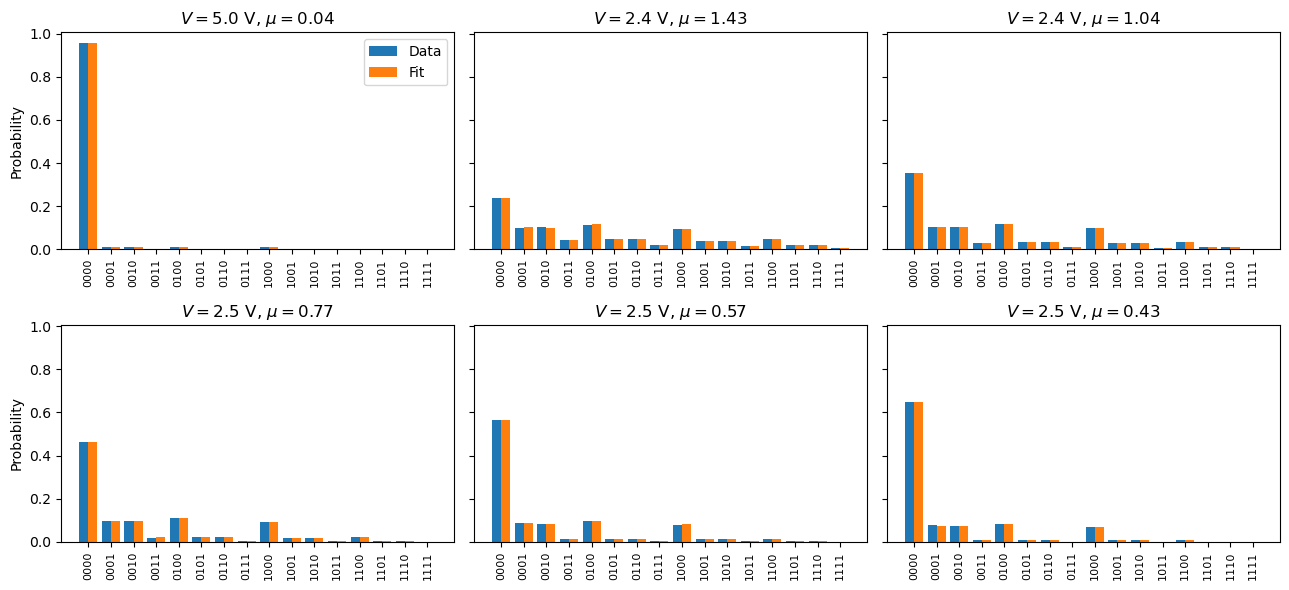

In [18]:
patterns = [f"{i:04b}" for i in range(16)]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
axes = axes.ravel()

x = np.arange(16)
w = 0.4

for i, (V, mu_eff) in enumerate(zip(voltage_arr, mu_eff_fit)):

    _, _, P_model, _ = simulate_pattern(
        signal_on=False,
        eta_w=1.0,
        mu=mu_eff,
        eta_pre=1.0,
        eta_post=1.0,
        weights1=weights_fit,
        eta_det1=1.0,
        R_dark1=R_dark_fit,
        weights2=weights_fit,
        eta_det2=1.0,
        R_dark2=R_dark_fit,
        tau_gate=tau_gate,
        phi=0.0
    )

    P_data = counts_arr[i] / counts_arr[i].sum()

    axes[i].bar(x - w/2, P_data, width=w, label="Data")
    axes[i].bar(x + w/2, P_model, width=w, label="Fit")

    axes[i].set_title(
        rf"$V={V:.1f}$ V, $\mu={mu_eff:.2f}$"
    )
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(patterns, rotation=90, fontsize=8)

axes[0].set_ylabel("Probability")
axes[3].set_ylabel("Probability")

axes[0].legend()

plt.tight_layout()
plt.show()

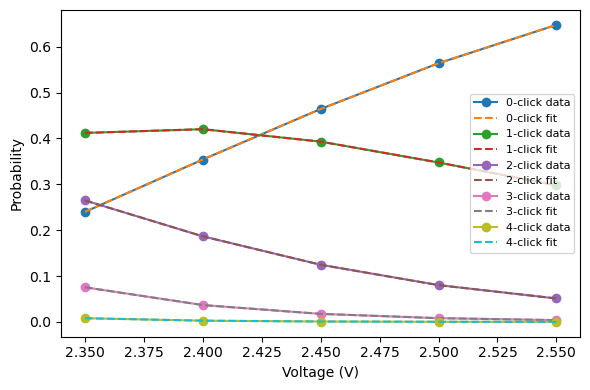

In [31]:
click_num = np.array([bin(i).count("1") for i in range(16)])

P_data_k = {k: [] for k in range(5)}
P_fit_k  = {k: [] for k in range(5)}

for i, mu_eff in enumerate(mu_eff_fit):

    _, _, P_model, _ = simulate_pattern(
        signal_on=False,
        eta_w=1.0,
        mu=mu_eff,
        eta_pre=1.0,
        eta_post=1.0,
        weights1=weights_fit,
        eta_det1=1.0,
        R_dark1=R_dark_fit,
        weights2=weights_fit,
        eta_det2=1.0,
        R_dark2=R_dark_fit,
        tau_gate=tau_gate,
        phi=0.0
    )

    P_data = counts_arr[i] / counts_arr[i].sum()

    for k in range(5):
        P_data_k[k].append(P_data[click_num == k].sum())
        P_fit_k[k].append(P_model[click_num == k].sum())

# draw
plt.figure(figsize=(6, 4))

for k in range(5):
    plt.plot(voltage_arr[1:], P_data_k[k][1:], 'o-', label=f"{k}-click data")
    plt.plot(voltage_arr[1:], P_fit_k[k][1:], '--', label=f"{k}-click fit")

plt.xlabel("Voltage (V)")
plt.ylabel("Probability")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

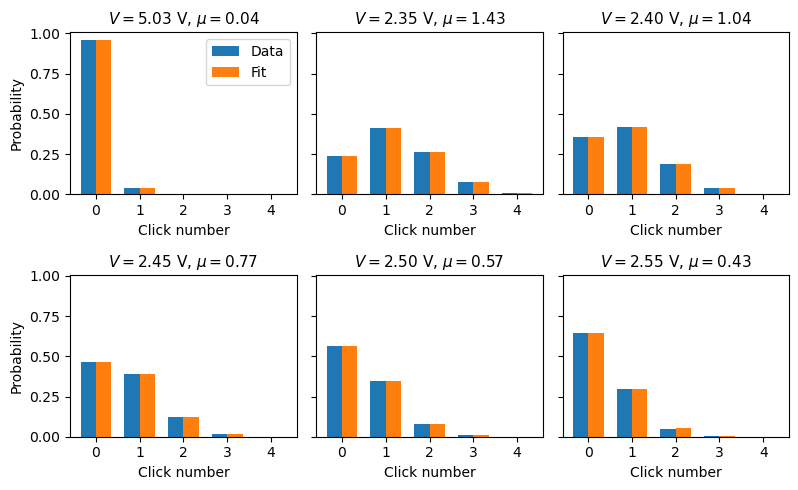

In [39]:
click_num = np.array([bin(i).count("1") for i in range(16)])
x = np.arange(5)
labels = ["0", "1", "2", "3", "4"]

fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharey=True)
axes = axes.ravel()
w = 0.35

for i, mu_eff in enumerate(mu_eff_fit):

    _, _, P_model, _ = simulate_pattern(
        signal_on=False,
        eta_w=1.0,
        mu=mu_eff,
        eta_pre=1.0,
        eta_post=1.0,
        weights1=weights_fit,
        eta_det1=1.0,
        R_dark1=R_dark_fit,
        weights2=weights_fit,
        eta_det2=1.0,
        R_dark2=R_dark_fit,
        tau_gate=tau_gate,
        phi=0.0
    )

    P_data = counts_arr[i] / counts_arr[i].sum()

    Pk_data = np.array([P_data[click_num == k].sum() for k in range(5)])
    Pk_fit  = np.array([P_model[click_num == k].sum() for k in range(5)])

    ax = axes[i]
    ax.bar(x - w/2, Pk_data, width=w, label="Data")
    ax.bar(x + w/2, Pk_fit,  width=w, label="Fit")

    ax.set_title(rf"$V={voltage_arr[i]:.2f}$ V, $\mu={mu_eff:.2f}$", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Click number", fontsize=10)
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=10)

axes[0].legend()

if len(voltage_arr) < len(axes):
    for j in range(len(voltage_arr), len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()